**Run the cell below first.** Its code is collapsed (click the `...` to
expand it) because it is one-time setup, not part of the lesson -- but it
still has to run once, before anything else in this notebook, or later
cells will fail with `NameError`. Click it, then press Shift+Enter (or the
Run button), and continue through the notebook in order from there.


In [ ]:
import sys
import warnings

# This notebook's pinned browser kernel renders every matplotlib figure
# through a backend/version combination that emits a benign
# MatplotlibDeprecationWarning about float pixel coordinates on EVERY figure
# it draws -- confirmed by testing a one-line plot with no custom code at
# all, so it is not something caused by any plotting choice in this
# notebook. Silencing only this exact upstream message (never deprecation
# warnings in general) keeps output clean without masking a real problem.
warnings.filterwarnings("ignore", message=r"The (width|height|x|y) parameter as float was deprecated")

# This notebook's pinned browser kernel's own threadpoolctl
# (imported internally by scikit-learn, not by this notebook) emits a
# RuntimeWarning every time a model is fit under Pyodide -- reproduced live
# in this exact browser build, in Section 7/8's figure cells, as:
#   threadpoolctl.py:1135: RuntimeWarning: JsProxy.as_object_map() is
#   deprecated. Use as_py_json() instead.
#     for filepath in LDSO.loadedLibsByName.as_object_map():
# The call site is threadpoolctl's own Pyodide shared-library introspection
# (LDSO.loadedLibsByName.as_object_map()), never a call this notebook's
# code makes -- not something a local source-text replacement or
# site-packages patch could reach without re-vendoring threadpoolctl itself
# inside this course's own JupyterLite build, which the current Pyodide
# distribution does not support overriding per-notebook. Filtered here by
# the identical exact message match, scoped to RuntimeWarning only -- never
# a blanket RuntimeWarning/DeprecationWarning suppression.
warnings.filterwarnings(
    "ignore",
    message=r"JsProxy\.as_object_map\(\) is deprecated",
    category=RuntimeWarning,
)

if sys.platform == "emscripten":
    # Running in the browser (JupyterLite). ipywidgets has no prebuilt
    # Pyodide package, unlike numpy/pandas/scikit-learn/matplotlib
    # (preloaded by the JupyterLite build, see book/lite/overrides.json),
    # so it is fetched here instead of by a student-run install cell.
    # Local Jupyter and Colab already have ipywidgets installed.
    import micropip

    await micropip.install(["ipywidgets"])

import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML

_ABIDE_LITE_FEATURES = [
    'fsCT_L_1_ROI', 'fsCT_R_1_ROI', 'fsCT_L_10d_ROI', 'fsCT_R_10d_ROI',
    'fsCT_L_10pp_ROI', 'fsCT_R_10pp_ROI', 'fsCT_L_10r_ROI', 'fsCT_R_10r_ROI',
    'fsCT_L_10v_ROI', 'fsCT_R_10v_ROI', 'fsCT_L_11l_ROI', 'fsCT_R_11l_ROI',
    'fsCT_L_13l_ROI', 'fsCT_R_13l_ROI', 'fsCT_L_2_ROI', 'fsCT_R_2_ROI',
    'fsCT_L_23c_ROI', 'fsCT_R_23c_ROI', 'fsCT_L_23d_ROI', 'fsCT_R_23d_ROI',
    'fsCT_L_24dd_ROI', 'fsCT_R_24dd_ROI', 'fsCT_L_24dv_ROI', 'fsCT_R_24dv_ROI',
    'fsCT_L_25_ROI', 'fsCT_R_25_ROI', 'fsCT_L_31a_ROI', 'fsCT_R_31a_ROI',
    'fsCT_L_31pd_ROI', 'fsCT_R_31pd_ROI', 'fsCT_L_31pv_ROI', 'fsCT_R_31pv_ROI',
    'fsCT_L_33pr_ROI', 'fsCT_R_33pr_ROI', 'fsCT_L_3a_ROI', 'fsCT_R_3a_ROI',
    'fsCT_L_3b_ROI', 'fsCT_R_3b_ROI', 'fsCT_L_4_ROI', 'fsCT_R_4_ROI',
    'fsCT_L_43_ROI', 'fsCT_R_43_ROI', 'fsCT_L_44_ROI', 'fsCT_R_44_ROI',
    'fsCT_L_45_ROI', 'fsCT_R_45_ROI', 'fsCT_L_46_ROI', 'fsCT_R_46_ROI',
    'fsCT_L_47l_ROI', 'fsCT_R_47l_ROI', 'fsCT_L_47m_ROI', 'fsCT_R_47m_ROI',
    'fsCT_L_47s_ROI', 'fsCT_R_47s_ROI', 'fsCT_L_5L_ROI', 'fsCT_R_5R_ROI',
    'fsCT_L_52_ROI', 'fsCT_R_52_ROI', 'fsCT_L_55b_ROI', 'fsCT_R_55b_ROI',
    'fsCT_L_5m_ROI', 'fsCT_R_5m_ROI', 'fsCT_L_5mv_ROI', 'fsCT_R_5mv_ROI',
    'fsCT_L_6a_ROI', 'fsCT_R_6a_ROI', 'fsCT_L_6d_ROI', 'fsCT_R_6d_ROI',
    'fsCT_L_6ma_ROI', 'fsCT_R_6ma_ROI', 'fsCT_L_6mp_ROI', 'fsCT_R_6mp_ROI',
    'fsCT_L_6r_ROI', 'fsCT_R_6r_ROI', 'fsCT_L_6v_ROI', 'fsCT_R_6v_ROI',
    'fsCT_L_7AL_ROI', 'fsCT_R_7AL_ROI', 'fsCT_L_7Am_ROI', 'fsCT_R_7Am_ROI',
    'fsCT_L_7PC_ROI', 'fsCT_R_7PC_ROI', 'fsCT_L_7PL_ROI', 'fsCT_R_7PL_ROI',
    'fsCT_L_7Pm_ROI', 'fsCT_R_7Pm_ROI', 'fsCT_L_7m_ROI', 'fsCT_R_7m_ROI',
    'fsCT_L_8Ad_ROI', 'fsCT_R_8Ad_ROI', 'fsCT_L_8Av_ROI', 'fsCT_R_8Av_ROI',
    'fsCT_L_8BL_ROI', 'fsCT_R_8BL_ROI', 'fsCT_L_8BM_ROI', 'fsCT_R_8BM_ROI',
    'fsCT_L_8C_ROI', 'fsCT_R_8C_ROI', 'fsCT_L_9-46d_ROI', 'fsCT_R_9-46d_ROI',
    'fsCT_L_9a_ROI', 'fsCT_R_9a_ROI', 'fsCT_L_9m_ROI', 'fsCT_R_9m_ROI',
    'fsCT_L_9p_ROI', 'fsCT_R_9p_ROI', 'fsCT_L_A1_ROI', 'fsCT_R_A1_ROI',
    'fsCT_L_A4_ROI', 'fsCT_R_A4_ROI', 'fsCT_L_A5_ROI', 'fsCT_R_A5_ROI',
    'fsCT_L_AAIC_ROI', 'fsCT_R_AAIC_ROI', 'fsCT_L_AIP_ROI', 'fsCT_R_AIP_ROI',
    'fsCT_L_AVI_ROI', 'fsCT_R_AVI_ROI', 'fsCT_L_DVT_ROI', 'fsCT_R_DVT_ROI',
    'fsCT_L_EC_ROI', 'fsCT_R_EC_ROI', 'fsCT_L_FEF_ROI', 'fsCT_R_FEF_ROI',
    'fsCT_L_FFC_ROI', 'fsCT_R_FFC_ROI', 'fsCT_L_FOP1_ROI', 'fsCT_R_FOP1_ROI',
    'fsCT_L_FOP2_ROI', 'fsCT_R_FOP2_ROI', 'fsCT_L_FOP3_ROI', 'fsCT_R_FOP3_ROI',
    'fsCT_L_FOP4_ROI', 'fsCT_R_FOP4_ROI', 'fsCT_L_FOP5_ROI', 'fsCT_R_FOP5_ROI',
    'fsCT_L_FST_ROI', 'fsCT_R_FST_ROI', 'fsCT_L_H_ROI', 'fsCT_R_H_ROI',
    'fsCT_L_IFJa_ROI', 'fsCT_R_IFJa_ROI', 'fsCT_L_IFJp_ROI', 'fsCT_R_IFJp_ROI',
    'fsCT_L_IFSa_ROI', 'fsCT_R_IFSa_ROI', 'fsCT_L_IFSp_ROI', 'fsCT_R_IFSp_ROI',
    'fsCT_L_IP0_ROI', 'fsCT_R_IP0_ROI', 'fsCT_L_IP1_ROI', 'fsCT_R_IP1_ROI',
    'fsCT_L_IP2_ROI', 'fsCT_R_IP2_ROI', 'fsCT_L_IPS1_ROI', 'fsCT_R_IPS1_ROI',
    'fsCT_L_Ig_ROI', 'fsCT_R_Ig_ROI', 'fsCT_L_LBelt_ROI', 'fsCT_R_LBelt_ROI',
    'fsCT_L_LIPd_ROI', 'fsCT_R_LIPd_ROI', 'fsCT_L_LIPv_ROI', 'fsCT_R_LIPv_ROI',
    'fsCT_L_LO1_ROI', 'fsCT_R_LO1_ROI', 'fsCT_L_LO2_ROI', 'fsCT_R_LO2_ROI',
    'fsCT_L_LO3_ROI', 'fsCT_R_LO3_ROI', 'fsCT_L_MBelt_ROI', 'fsCT_R_MBelt_ROI',
    'fsCT_L_MI_ROI', 'fsCT_R_MI_ROI', 'fsCT_L_MIP_ROI', 'fsCT_R_MIP_ROI',
    'fsCT_L_MST_ROI', 'fsCT_R_MST_ROI', 'fsCT_L_MT_ROI', 'fsCT_R_MT_ROI',
    'fsCT_L_OFC_ROI', 'fsCT_R_OFC_ROI', 'fsCT_L_OP1_ROI', 'fsCT_R_OP1_ROI',
    'fsCT_L_OP2-3_ROI', 'fsCT_R_OP2-3_ROI', 'fsCT_L_OP4_ROI', 'fsCT_R_OP4_ROI',
    'fsCT_L_PBelt_ROI', 'fsCT_R_PBelt_ROI', 'fsCT_L_PCV_ROI', 'fsCT_R_PCV_ROI',
    'fsCT_L_PEF_ROI', 'fsCT_R_PEF_ROI', 'fsCT_L_PF_ROI', 'fsCT_R_PF_ROI',
    'fsCT_L_PFcm_ROI', 'fsCT_R_PFcm_ROI', 'fsCT_L_PFm_ROI', 'fsCT_R_PFm_ROI',
    'fsCT_L_PFop_ROI', 'fsCT_R_PFop_ROI', 'fsCT_L_PFt_ROI', 'fsCT_R_PFt_ROI',
    'fsCT_L_PGi_ROI', 'fsCT_R_PGi_ROI', 'fsCT_L_PGp_ROI', 'fsCT_R_PGp_ROI',
    'fsCT_L_PGs_ROI', 'fsCT_R_PGs_ROI', 'fsCT_L_PH_ROI', 'fsCT_R_PH_ROI',
    'fsCT_L_PHA1_ROI', 'fsCT_R_PHA1_ROI', 'fsCT_L_PHA2_ROI', 'fsCT_R_PHA2_ROI',
    'fsCT_L_PHA3_ROI', 'fsCT_R_PHA3_ROI', 'fsCT_L_PHT_ROI', 'fsCT_R_PHT_ROI',
    'fsCT_L_PI_ROI', 'fsCT_R_PI_ROI', 'fsCT_L_PIT_ROI', 'fsCT_R_PIT_ROI',
    'fsCT_L_POS1_ROI', 'fsCT_R_POS1_ROI', 'fsCT_L_POS2_ROI', 'fsCT_R_POS2_ROI',
    'fsCT_L_PSL_ROI', 'fsCT_R_PSL_ROI', 'fsCT_L_PeEc_ROI', 'fsCT_R_PeEc_ROI',
    'fsCT_L_Pir_ROI', 'fsCT_R_Pir_ROI', 'fsCT_L_PoI1_ROI', 'fsCT_R_PoI1_ROI',
    'fsCT_L_PoI2_ROI', 'fsCT_R_PoI2_ROI', 'fsCT_L_PreS_ROI', 'fsCT_R_PreS_ROI',
    'fsCT_L_ProS_ROI', 'fsCT_R_ProS_ROI', 'fsCT_L_RI_ROI', 'fsCT_R_RI_ROI',
    'fsCT_L_RSC_ROI', 'fsCT_R_RSC_ROI', 'fsCT_L_SCEF_ROI', 'fsCT_R_SCEF_ROI',
    'fsCT_L_SFL_ROI', 'fsCT_R_SFL_ROI', 'fsCT_L_STGa_ROI', 'fsCT_R_STGa_ROI',
    'fsCT_L_STSda_ROI', 'fsCT_R_STSda_ROI', 'fsCT_L_STSdp_ROI', 'fsCT_R_STSdp_ROI',
    'fsCT_L_STSva_ROI', 'fsCT_R_STSva_ROI', 'fsCT_L_STSvp_ROI', 'fsCT_R_STSvp_ROI',
    'fsCT_L_STV_ROI', 'fsCT_R_STV_ROI', 'fsCT_L_TA2_ROI', 'fsCT_R_TA2_ROI',
    'fsCT_L_TE1a_ROI', 'fsCT_R_TE1a_ROI', 'fsCT_L_TE1m_ROI', 'fsCT_R_TE1m_ROI',
    'fsCT_L_TE1p_ROI', 'fsCT_R_TE1p_ROI', 'fsCT_L_TE2a_ROI', 'fsCT_R_TE2a_ROI',
    'fsCT_L_TE2p_ROI', 'fsCT_R_TE2p_ROI', 'fsCT_L_TF_ROI', 'fsCT_R_TF_ROI',
    'fsCT_L_TGd_ROI', 'fsCT_R_TGd_ROI', 'fsCT_L_TGv_ROI', 'fsCT_R_TGv_ROI',
    'fsCT_L_TPOJ1_ROI', 'fsCT_R_TPOJ1_ROI', 'fsCT_L_TPOJ2_ROI', 'fsCT_R_TPOJ2_ROI',
    'fsCT_L_TPOJ3_ROI', 'fsCT_R_TPOJ3_ROI', 'fsCT_L_V1_ROI', 'fsCT_R_V1_ROI',
    'fsCT_L_V2_ROI', 'fsCT_R_V2_ROI', 'fsCT_L_V3_ROI', 'fsCT_R_V3_ROI',
    'fsCT_L_V3A_ROI', 'fsCT_R_V3A_ROI', 'fsCT_L_V3B_ROI', 'fsCT_R_V3B_ROI',
    'fsCT_L_V3CD_ROI', 'fsCT_R_V3CD_ROI', 'fsCT_L_V4_ROI', 'fsCT_R_V4_ROI',
    'fsCT_L_V4t_ROI', 'fsCT_R_V4t_ROI', 'fsCT_L_V6_ROI', 'fsCT_R_V6_ROI',
    'fsCT_L_V6A_ROI', 'fsCT_R_V6A_ROI', 'fsCT_L_V7_ROI', 'fsCT_R_V7_ROI',
    'fsCT_L_V8_ROI', 'fsCT_R_V8_ROI', 'fsCT_L_VIP_ROI', 'fsCT_R_VIP_ROI',
    'fsCT_L_VMV1_ROI', 'fsCT_R_VMV1_ROI', 'fsCT_L_VMV2_ROI', 'fsCT_R_VMV2_ROI',
    'fsCT_L_VMV3_ROI', 'fsCT_R_VMV3_ROI', 'fsCT_L_VVC_ROI', 'fsCT_R_VVC_ROI',
    'fsCT_L_a10p_ROI', 'fsCT_R_a10p_ROI', 'fsCT_L_a24_ROI', 'fsCT_R_a24_ROI',
    'fsCT_L_a24pr_ROI', 'fsCT_R_a24pr_ROI', 'fsCT_L_a32pr_ROI', 'fsCT_R_a32pr_ROI',
    'fsCT_L_a47r_ROI', 'fsCT_R_a47r_ROI', 'fsCT_L_a9-46v_ROI', 'fsCT_R_a9-46v_ROI',
    'fsCT_L_d23ab_ROI', 'fsCT_R_d23ab_ROI', 'fsCT_L_d32_ROI', 'fsCT_R_d32_ROI',
    'fsCT_L_i6-8_ROI', 'fsCT_R_i6-8_ROI', 'fsCT_L_p10p_ROI', 'fsCT_R_p10p_ROI',
    'fsCT_L_p24_ROI', 'fsCT_R_p24_ROI', 'fsCT_L_p24pr_ROI', 'fsCT_R_p24pr_ROI',
    'fsCT_L_p32_ROI', 'fsCT_R_p32_ROI', 'fsCT_L_p32pr_ROI', 'fsCT_R_p32pr_ROI',
    'fsCT_L_p47r_ROI', 'fsCT_R_p47r_ROI', 'fsCT_L_p9-46v_ROI', 'fsCT_R_p9-46v_ROI',
    'fsCT_L_pOFC_ROI', 'fsCT_R_pOFC_ROI', 'fsCT_L_s32_ROI', 'fsCT_R_s32_ROI',
    'fsCT_L_s6-8_ROI', 'fsCT_R_s6-8_ROI', 'fsCT_L_v23ab_ROI', 'fsCT_R_v23ab_ROI',
]


def load_abide_age_brain_table():
    """Return the age/brain table: 360 cortical-thickness predictors, age,
    and group (autism/control, used only to reproduce the established
    train/test split -- never a model feature).

    Tries the small same-origin file this notebook ships next to first
    (JupyterLite, or a full local checkout); falls back to the same
    pinned, checksummed public source this course already uses elsewhere
    (a bare downloaded .ipynb, or Colab, neither of which has the sibling
    data file). Both paths return identically shaped, identically ordered
    columns, so the rest of this notebook never needs to know which one
    ran.
    """
    from pathlib import Path

    local_path = Path("data/abide_age_brain.csv")
    if local_path.exists():
        table = pd.read_csv(local_path)
    else:
        url = (
            "https://raw.githubusercontent.com/neurohackademy/nh2020-curriculum/"
            "e4eed3c4daa7f40b0ba931182a8c7e5e691dba6b/"
            "tu-machine-learning-yarkoni/data/abide2.tsv"
        )
        table = pd.read_csv(url, sep="\t")
    table = table.dropna(subset=["age"])
    return table[_ABIDE_LITE_FEATURES + ["age", "group"]].reset_index(drop=True)


# Keeps every checked question's option text wrapping within the notebook's
# own width, at any viewport, instead of being cut off with an ellipsis.
_QUESTION_CSS = """
<style>
.checked-question .widget-checkbox { width: 100% !important; height: auto !important; }
.checked-question .widget-label-basic {
    width: 100% !important;
    white-space: normal !important;
    overflow: visible !important;
    text-overflow: unset !important;
    height: auto !important;
}
.checked-question .widget-radio-box { width: 100% !important; }
.checked-question .widget-radio-box label {
    width: 100% !important;
    max-width: 100% !important;
    white-space: normal !important;
    height: auto !important;
    box-sizing: border-box;
    padding: 3px 0;
    line-height: 1.3;
}
</style>
"""


def _question_style_widget():
    # Zero-height so it adds no visible gap; the <style> tag itself applies
    # document-wide regardless of where it sits in the DOM.
    return widgets.HTML(_QUESTION_CSS, layout=widgets.Layout(height="0px", margin="0px", padding="0px"))


def make_single_choice_question(prompt, options, correct_index, feedback_correct="Correct.", feedback_incorrect="Not quite -- try again."):
    """A compact single-choice checked question. Returns a widget to display()."""
    radio = widgets.RadioButtons(options=list(options), description="", layout=widgets.Layout(width="100%"))
    button = widgets.Button(description="Check answer", button_style="primary")
    feedback = widgets.Output()

    def _on_click(_button):
        with feedback:
            feedback.clear_output(wait=True)
            print(feedback_correct if radio.index == correct_index else feedback_incorrect)

    button.on_click(_on_click)
    box = widgets.VBox(
        [_question_style_widget(), widgets.HTML(f"<b>{prompt}</b>"), radio, button, feedback],
        layout=widgets.Layout(width="100%"),
    )
    box.add_class("checked-question")
    return box


def make_multi_choice_question(prompt, options, correct_indices, feedback_correct="Correct.", feedback_incorrect="Not quite -- try again."):
    """A compact multiple-selection checked question. Returns a widget to display()."""
    correct = set(correct_indices)
    boxes = [
        widgets.Checkbox(value=False, description=opt, indent=False, layout=widgets.Layout(width="100%"))
        for opt in options
    ]
    button = widgets.Button(description="Check answer", button_style="primary")
    feedback = widgets.Output()

    def _on_click(_button):
        selected = {i for i, cb in enumerate(boxes) if cb.value}
        with feedback:
            feedback.clear_output(wait=True)
            print(feedback_correct if selected == correct else feedback_incorrect)

    button.on_click(_on_click)
    box = widgets.VBox(
        [_question_style_widget(), widgets.HTML(f"<b>{prompt}</b>")] + boxes + [button, feedback],
        layout=widgets.Layout(width="100%"),
    )
    box.add_class("checked-question")
    return box


# Question content lives here, not in the visible cell that displays it: a
# visible call like show_question("q-knn-complexity") never prints or displays
# a correct_index/correct_indices value. This is visual concealment, not
# secure assessment: the hidden cell is fully expandable, and a downloaded,
# fully offline, editable notebook must contain enough information to check an
# answer locally, so a technically curious student can always recover it from
# source or the running kernel.
_QUESTIONS = {
    "q-test-target-use": dict(
        kind="multi",
        prompt="Which uses of the test target y_test are allowed at this point in the notebook?",
        options=[
            "Plotting its distribution to sanity-check the split (as above).",
            "Choosing which features to use because they correlate well with y_test.",
            "Reporting its mean and standard deviation.",
            "Tuning the model's settings so the test score looks better.",
        ],
        correct_indices={0, 2},
    ),
    "q-correlation-vs-coefficient": dict(
        kind="multi",
        prompt="Why can a feature's correlation with age and its fitted regression coefficient tell different stories?",
        options=[
            "Correlation is a marginal (feature-by-itself) relationship; a coefficient is conditional on every other feature already being in the model.",
            "Correlated predictors can share credit: a coefficient can shrink even for a feature with a strong marginal correlation once correlated neighbours absorb that signal.",
            "Coefficients are computed on the test set, so they answer a different question than a training-only correlation.",
            "The two measures are mathematically identical whenever the model is linear.",
        ],
        correct_indices={0, 1},
    ),
    "q-honest-evaluation": dict(
        kind="single",
        prompt="Which evaluation can estimate performance for a new participant?",
        options=["A. correct", "B. training score", "C. invalid"],
        correct_index=0,
        feedback_correct="Correct: only scoring on held-out rows the model never touched during fitting estimates performance on a new participant.",
        feedback_incorrect="Not quite -- both training-row evaluation and fitting on test rows are misleading.",
    ),
    "q-knn-complexity": dict(
        kind="single",
        prompt="Which of these changes increases KNN's model complexity?",
        options=["Decreasing k", "Increasing k", "Model complexity does not depend on k"],
        correct_index=0,
    ),
    "q-knn-large-k-variance": dict(
        kind="single",
        prompt="In this activity, what happens to the three training-sample resamples' scatter as k grows very large?",
        options=[
            "They converge toward the same near-constant predictions.",
            "They spread further apart from each other.",
            "They become identical to the k=1 scatter.",
        ],
        correct_index=0,
        feedback_correct="Correct: at large k every resample averages over nearly the whole fitting set, so predictions converge toward the fitting-set mean regardless of which participants happened to be resampled.",
    ),
}


def show_question(question_id):
    q = _QUESTIONS[question_id]
    if q["kind"] == "single":
        widget = make_single_choice_question(
            q["prompt"],
            q["options"],
            q["correct_index"],
            q.get("feedback_correct", "Correct."),
            q.get("feedback_incorrect", "Not quite -- try again."),
        )
    else:
        widget = make_multi_choice_question(
            q["prompt"],
            q["options"],
            q["correct_indices"],
            q.get("feedback_correct", "Correct."),
            q.get("feedback_incorrect", "Not quite -- try again."),
        )
    display(widget)


def annotate_model_complexity_axis(ax, k_ticks, n_max):
    """Log-scale an Axes' x-axis as "Model complexity" (1/k) and label a few
    k values directly on it. Returns nothing; modifies ax in place."""
    ax.set_xscale("log")
    ax.set_xlabel("Model complexity")
    ax.set_title(ax.get_title(), pad=26)  # room for the (possibly staggered) k= labels below it
    trans = ax.get_xaxis_transform()  # x in data coords, y in axes-fraction
    # Two nearby k values (e.g. the k with lowest validation error landing
    # next to a round number like 20) can land close enough on a log axis
    # that their labels would overlap at the same height -- alternating the
    # vertical offset by position avoids that regardless of exact spacing.
    for i, k in enumerate(sorted(set(k for k in k_ticks if 1 <= k <= n_max))):
        x = 1.0 / k
        ax.axvline(x, color="0.85", lw=0.6, zorder=0)
        ax.annotate(
            f"k={k}",
            xy=(x, 1.0),
            xycoords=trans,
            xytext=(0, 4 if i % 2 == 0 else 15),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=7,
            color="0.35",
        )


# Exercise 2: Regression and Bias-Variance Trade-Off


## What this notebook covers

You will use linear regression and k-nearest-neighbours (KNN) regression to
predict a participant's **age** from their ABIDE-II brain measurements. Some
cells are supplied and ready to run; others ask you to write a few lines
yourself, answer a question in writing, or answer a checked question with
immediate feedback. Along the way you will explore how model complexity
trades bias against variance.

Written-answer cells (like the bold question below) are ordinary Markdown:
double-click one to edit it, type your answer, then press Shift+Enter to
render it back. Your answer is saved with the rest of this notebook,
including in **Download my notebook**.


## Section 1 — Load data and prepare the split


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


In [ ]:
# Load the established ABIDE-II age/brain table.
try:
    data = load_abide_age_brain_table()
except NameError as exc:
    raise RuntimeError(
        "load_abide_age_brain_table is not defined yet. Run this notebook's "
        "first code cell (collapsed, at the very top, under 'Run the cell "
        "below first') before this one, then run this cell again."
    ) from exc
FEATURES = [c for c in data.columns if c not in ("age", "group")]
print(f"{len(data)} participants, {len(FEATURES)} brain predictors")
data.head()


In [ ]:
# Define the target (age) and the feature matrix, then make the established
# reproducible split: 25% held out, stratified by diagnostic group so train
# and test have a similar autism/control mix.
X = data[FEATURES].to_numpy()
y = data["age"].to_numpy()
groups = data["group"].to_numpy()

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups, test_size=0.25, random_state=42, stratify=groups
)
print(f"n_train = {len(y_train)}   n_test = {len(y_test)}")


In [ ]:
# Fit the scaler on training predictors only, then transform both sets.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Section 2 — Inspect the split before modelling


A practical check before fitting anything: are the train and test targets reasonably similar, and which features look related to age?


### Activity 2A — Compare target distributions


Write code that:
- plots `y_train` and `y_test` using the **same bins and axis range**;
- reports n, mean, standard deviation, minimum, and maximum for each;
- uses readable labels and a legend.


In [ ]:
bins = np.linspace(min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max()), 25)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(y_train, bins=bins, alpha=0.6, label=f"train (n={len(y_train)})", density=True)
ax.hist(y_test, bins=bins, alpha=0.6, label=f"test (n={len(y_test)})", density=True)
ax.set_xlabel("age (years)")
ax.set_ylabel("density")
ax.set_title("Train vs. test age distribution")
ax.legend()
plt.show()

for name, arr in [("train", y_train), ("test", y_test)]:
    print(f"{name}: n={len(arr)}  mean={arr.mean():.1f}  sd={arr.std():.1f}  min={arr.min():.1f}  max={arr.max():.1f}")


> **Are the two distributions similar enough for this exercise? Name one similarity and one difference. Do not choose model settings from the test distribution.**


In [ ]:
show_question("q-test-target-use")


### Activity 2B — Find features correlated with age


Write **training-only** code that:
- calculates the Pearson correlation between every brain feature and `y_train`;
- sorts by absolute correlation;
- displays and plots the ten strongest relationships, preserving sign;
- uses shortened, readable region labels.


In [ ]:
train_df = pd.DataFrame(X_train, columns=FEATURES)
correlations = train_df.apply(lambda col: np.corrcoef(col, y_train)[0, 1])
top10 = correlations.reindex(correlations.abs().sort_values(ascending=False).index[:10])
short_labels = [c.replace("fsCT_", "").replace("_ROI", "") for c in top10.index]

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#2a6f9e" if v > 0 else "#b5622f" for v in top10.values]
ax.barh(short_labels[::-1], top10.values[::-1], color=colors[::-1])
ax.set_xlabel("Pearson correlation with age (training rows only)")
ax.set_title("Ten strongest age-correlated features")
plt.tight_layout()
plt.show()
display(top10.rename("correlation").to_frame())


> **Which two or three features do you expect to have large fitted coefficients, and why?**


## Section 3 — Fit linear regression


This is your first regression workflow, so it is supplied in full.


In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
test_r2 = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
print(f"held-out R^2 = {test_r2:.3f}")
print(f"held-out MSE = {test_mse:.1f}  (RMSE {test_mse ** 0.5:.1f} years)")


### Activity 3A — Inspect coefficients


Write code that:
- pairs the 360 feature names with their fitted coefficients;
- sorts by absolute magnitude;
- selects a readable number of the largest positive and negative coefficients;
- draws a labelled horizontal bar plot;
- describes the coefficient axis correctly for **standardized** predictors.


In [ ]:
coefs = pd.Series(model.coef_, index=FEATURES)
top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index[:10])
short_labels = [c.replace("fsCT_", "").replace("_ROI", "") for c in top_coefs.index]

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#2a6f9e" if v > 0 else "#b5622f" for v in top_coefs.values]
ax.barh(short_labels[::-1], top_coefs.values[::-1], color=colors[::-1])
ax.set_xlabel("fitted coefficient (years per 1 SD of standardized cortical thickness)")
ax.set_title("Ten largest-magnitude linear-regression coefficients")
plt.tight_layout()
plt.show()


> **Compare this ranking with Activity 2B's correlation ranking. Which features appear on both lists, and which do not?**


In [ ]:
show_question("q-correlation-vs-coefficient")


Marginal correlations and multivariable coefficients need not rank features identically -- a feature can correlate strongly with age on its own yet receive a small coefficient once correlated neighbouring regions are already in the model, and vice versa.


### Activity 3B — Create an observed-versus-predicted plot


Create an observed-versus-predicted scatter plot from `y_test` and `y_pred`.
Your plot should have:

- observed age on the x-axis, predicted age on the y-axis;
- a visible perfect-prediction diagonal;
- readable axis labels;
- a useful title.

For reference, here is the approved current result:


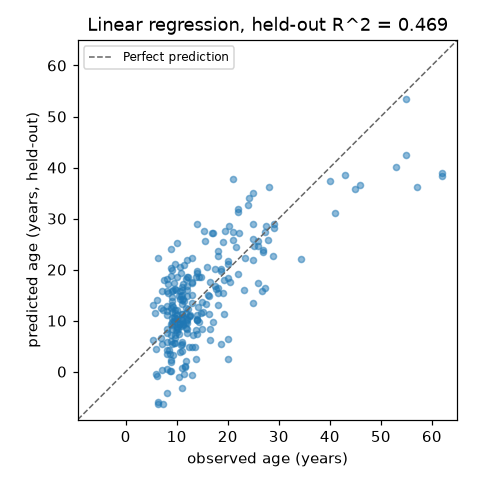


In [ ]:
fig, ax = plt.subplots(figsize=(4.4, 4.4))
lims = [min(y_test.min(), y_pred.min()) - 3, max(y_test.max(), y_pred.max()) + 3]
ax.plot(lims, lims, "--", color="0.4", lw=1, label="Perfect prediction")
ax.scatter(y_test, y_pred, s=16, alpha=0.5)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel("observed age (years)")
ax.set_ylabel("predicted age (years, held-out)")
ax.set_title(f"Linear regression, held-out R^2 = {test_r2:.3f}")
ax.legend(loc="upper left", fontsize=8)
plt.show()


> **Reflect: How closely do the held-out points track the diagonal? Where do the largest errors fall?**


## Section 4 — Correct and misleading evaluation


Same fixed split, same recipe, three ways to score the same model.


In [ ]:
train_pred = model.predict(X_train_scaled)
train_r2 = r2_score(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)

# A deliberately INVALID model: fit on the test rows, scored on those same
# test rows. Note n_test (251) is smaller than the number of features (360),
# so this fit is not just optimistic -- it is underdetermined.
invalid_model = LinearRegression().fit(X_test_scaled, y_test)
invalid_pred = invalid_model.predict(X_test_scaled)
invalid_r2 = r2_score(y_test, invalid_pred)
invalid_mse = mean_squared_error(y_test, invalid_pred)

comparison = pd.DataFrame(
    {
        "fit on": ["training rows", "training rows", "test rows (INVALID)"],
        "evaluated on": ["test rows", "training rows", "same test rows"],
        "R^2": [test_r2, train_r2, invalid_r2],
        "MSE": [test_mse, train_mse, invalid_mse],
    },
    index=["A. correct", "B. training score", "C. invalid"],
)
# Left-align every cell, including headers: pandas' default (index left,
# headers centered, numbers right) is set by the Book theme's own CSS in
# some environments but not others (plain nbconvert/local Jupyter/Colab).
# `to_html()` plus a small scoped <style> looks the same everywhere, with no
# dependency on the Book theme -- and no dependency on jinja2 either, unlike
# `DataFrame.style` (which is not preloaded in this notebook's browser
# kernel and is not guaranteed present in a bare downloaded/Colab copy).
table_html = comparison.round(3).to_html(classes="ex2-eval-table", border=0)
# !important is required: JupyterLab's own dataframe stylesheet
# (.dataframe th/td) otherwise outranks this rule -- confirmed live (without
# it, the header row's inherited "text-align: right" from pandas' own
# `to_html()` output wins even though this rule also directly targets th/td).
display(HTML(f'<style>.ex2-eval-table th, .ex2-eval-table td {{ text-align: left !important; }}</style>{table_html}'))


**B is not a competing model.** A high training score next to a lower test score is the signature of a model fitting noise it cannot reproduce on new data. **C is not a competing model either** -- with 360 features and only 251 test rows, fitting on the test rows is underdetermined and reproduces those rows almost exactly, which is not the same as learning something that generalises.


In [ ]:
show_question("q-honest-evaluation")


## Section 5 — Build KNN regression yourselves


KNN predicts a participant's age from the ages of the `k` nearest training participants (by feature distance). `k` controls model complexity: it is yours to build this time.


Write code that:
1. imports `KNeighborsRegressor`;
2. creates a model with `k=20`;
3. fits it on `X_train_scaled` and `y_train`;
4. predicts `X_test_scaled`;
5. calculates R² and MSE;
6. produces an observed-versus-predicted plot;
7. compares it with linear regression in the answer cell below.


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=20)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_r2 = r2_score(y_test, knn_pred)
knn_mse = mean_squared_error(y_test, knn_pred)
print(f"KNN (k=20) held-out R^2 = {knn_r2:.3f}")
print(f"KNN (k=20) held-out MSE = {knn_mse:.1f}  (RMSE {knn_mse ** 0.5:.1f} years)")

fig, ax = plt.subplots(figsize=(4.4, 4.4))
lims = [min(y_test.min(), knn_pred.min()) - 3, max(y_test.max(), knn_pred.max()) + 3]
ax.plot(lims, lims, "--", color="0.4", lw=1, label="Perfect prediction")
ax.scatter(y_test, knn_pred, s=16, alpha=0.5)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel("observed age (years)")
ax.set_ylabel("predicted age (years, held-out)")
ax.set_title(f"KNN (k=20), held-out R^2 = {knn_r2:.3f}")
ax.legend(loc="upper left", fontsize=8)
plt.show()


> **How does KNN (k=20) compare with linear regression on this same split?**


In [ ]:
# Run this to check your KNN results.
EXPECTED_KNN_R2 = 0.664
EXPECTED_KNN_MSE = 31.4
R2_TOLERANCE = 0.05  # generous: absorbs reasonable implementation differences
MSE_TOLERANCE = 3.0

if "knn_pred" in globals() and "knn_r2" in globals() and "knn_mse" in globals():
    assert len(knn_pred) == len(y_test), "knn_pred should have one prediction per test row"
    assert np.isfinite(knn_r2) and np.isfinite(knn_mse), "R^2 and MSE should be finite numbers"
    r2_close = abs(knn_r2 - EXPECTED_KNN_R2) <= R2_TOLERANCE
    mse_close = abs(knn_mse - EXPECTED_KNN_MSE) <= MSE_TOLERANCE
    if r2_close and mse_close:
        print(
            f"Looks good: R^2={knn_r2:.3f} and MSE={knn_mse:.1f} are within the "
            f"expected range for k=20 (R^2~{EXPECTED_KNN_R2}, MSE~{EXPECTED_KNN_MSE})."
        )
    else:
        print(
            f"Your result (R^2={knn_r2:.3f}, MSE={knn_mse:.1f}) differs from the "
            f"expected k=20 result (R^2~{EXPECTED_KNN_R2}, MSE~{EXPECTED_KNN_MSE}). "
            "That does not automatically mean something is wrong -- a different "
            "valid implementation, or an earlier choice in data loading, the "
            "train/test split, or scaling, can shift these numbers. Check that "
            "you used k=20 and the scaled X_train_scaled/X_test_scaled from "
            "Section 1 before assuming this is an error."
        )
else:
    print("Not complete yet: define knn_pred, knn_r2, and knn_mse above first.")


## Section 6 — Bias and variance


For a model predicting outcome $Y$ from features $X$, the expected squared
prediction error on a new observation decomposes as

$$\mathbb{E}\left[(Y-\hat f(X))^2\right] = \operatorname{Bias}(\hat f(X))^2 + \operatorname{Var}(\hat f(X)) + \sigma^2.$$

For KNN, `k` controls this directly:

- **small `k`** means greater model complexity, lower bias, and higher variance;
- **large `k`** means lower model complexity, higher bias, and lower variance.


This is a schematic illustration, not measured from the ABIDE data -- Section 7 computes the empirical analogue.

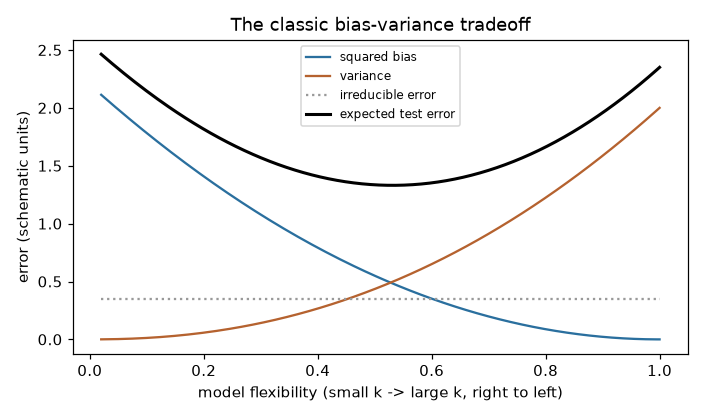


In [ ]:
show_question("q-knn-complexity")


## Section 7 — Performance across model complexity


In [ ]:
# This section uses only the outer-training partition (X_train, y_train) --
# the outer test set from Sections 3-5 is never touched here. Split it again
# into a fitting group and a validation group.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=7, stratify=groups_train
)
N_FIT = len(y_fit)

scaler_dev = StandardScaler().fit(X_fit)
Xf = scaler_dev.transform(X_fit)
Xv = scaler_dev.transform(X_val)


def _sorted_neighbor_targets(X_query, X_ref, y_ref):
    d = np.linalg.norm(X_query[:, None, :] - X_ref[None, :, :], axis=2)
    order = np.argsort(d, axis=1, kind="stable")
    return y_ref[order]


sorted_val = _sorted_neighbor_targets(Xv, Xf, y_fit)
sorted_fit = _sorted_neighbor_targets(Xf, Xf, y_fit)
ks = np.arange(1, N_FIT + 1)
val_pred_by_k = np.cumsum(sorted_val, axis=1) / ks
fit_pred_by_k = np.cumsum(sorted_fit, axis=1) / ks
val_mse = ((val_pred_by_k - y_val[:, None]) ** 2).mean(axis=0)
fit_mse = ((fit_pred_by_k - y_fit[:, None]) ** 2).mean(axis=0)
val_optimal_k = int(ks[np.argmin(val_mse)])
print(f"fitting participants = {N_FIT}   validation participants = {len(y_val)}")
print(f"k with lowest validation error = {val_optimal_k}")


In [ ]:
# Model complexity increases as k decreases. A log scale keeps every tested
# k readable at once (a linear 1/k axis crowds most of them near zero);
# integer k values are labelled directly above the curve.
complexity = 1.0 / ks

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(complexity, fit_mse, label="fitting MSE (resubstitution)", color="#2a6f9e")
ax.plot(complexity, val_mse, label="validation MSE", color="#b5622f")
ax.axvline(1.0 / val_optimal_k, color="0.6", lw=1, ls=":")
ax.set_ylabel("mean squared error (years$^2$)")
ax.set_title("Fitting vs. validation error across model complexity")
ax.legend(fontsize=8)
annotate_model_complexity_axis(ax, [N_FIT, 100, 20, val_optimal_k, 5, 1], N_FIT)
plt.tight_layout()
plt.show()


Fitting error keeps falling as complexity grows (perfect at k=1, the same resubstitution optimism from Section 4) while validation error is lowest at an intermediate complexity and rises again toward both ends -- the empirical signature of the classic bias-variance curve from Section 6.


## Section 8 — Explore model complexity


Move the slider or type a value to refit KNN at a different `k` and watch the observed-versus-predicted plot and the error curve position change together. Three deterministic training-sample resamples are overlaid so you can see how much predictions shift at a given `k` just from which fitting participants happened to be drawn.


In [ ]:
# This activity's own KNN fits do not depend on Section 5's import: it runs
# correctly whether or not you have completed that activity yet.
from sklearn.neighbors import KNeighborsRegressor

_rng = np.random.default_rng(41)
_resample_idx = [_rng.choice(N_FIT, size=N_FIT, replace=True) for _ in range(3)]
_resample_colors = ["#2a6f9e", "#b5622f", "#4c9a5b"]

k_slider = widgets.IntSlider(value=20, min=1, max=N_FIT, step=1, description="k:")
k_input = widgets.BoundedIntText(value=20, min=1, max=N_FIT, description="k (exact):")
k_output = widgets.Output()


def _explore_refit(k):
    with k_output:
        k_output.clear_output(wait=True)
        fig, (ax_scatter, ax_curve) = plt.subplots(1, 2, figsize=(10, 4))

        for idx, color in zip(_resample_idx, _resample_colors):
            model_r = KNeighborsRegressor(n_neighbors=k).fit(Xf[idx], y_fit[idx])
            pred_r = model_r.predict(Xv)
            ax_scatter.scatter(y_val, pred_r, s=12, alpha=0.5, color=color)
        lims = [y_val.min() - 3, y_val.max() + 3]
        ax_scatter.plot(lims, lims, "--", color="0.4", lw=1)
        ax_scatter.set_xlim(lims)
        ax_scatter.set_ylim(lims)
        ax_scatter.set_aspect("equal")
        ax_scatter.set_xlabel("observed age (years)")
        ax_scatter.set_ylabel("predicted age (years)")
        ax_scatter.set_title(f"k={k}  (three training-sample resamples)")

        ax_curve.plot(1.0 / ks, fit_mse, color="#2a6f9e", label="fitting MSE")
        ax_curve.plot(1.0 / ks, val_mse, color="#b5622f", label="validation MSE")
        ax_curve.axvline(1.0 / k, color="black", lw=1.5)
        ax_curve.set_ylabel("mean squared error (years$^2$)")
        ax_curve.set_title("Your current k on the error curve")
        ax_curve.legend(fontsize=8)
        annotate_model_complexity_axis(ax_curve, [N_FIT, 100, 20, k, 5, 1], N_FIT)
        plt.tight_layout()
        plt.show()
        print(f"k = {k}   model complexity (1/k) = {1.0 / k:.3f}")


def _on_k_change(change):
    if change["name"] == "value":
        k_input.value = change["new"]
        k_slider.value = change["new"]
        _explore_refit(change["new"])


k_slider.observe(_on_k_change, names="value")
k_input.observe(_on_k_change, names="value")
display(widgets.VBox([k_slider, k_input, k_output]))
_explore_refit(k_slider.value)


In [ ]:
show_question("q-knn-large-k-variance")


## Bonus — Feature sets and sample size


This section is optional and not required for the core session, and it is a teaching demonstration, not a rigorous protocol: trying many feature sets or sample sizes below is exploratory comparison, not formal feature selection -- the held-out score of the best-looking option is not an unbiased estimate of its true performance. The 10-feature set below was fixed in advance and is not chosen by ranking feature correlations the way Activity 2B did.


In [ ]:
# A small, fixed 10-column cortical-thickness subset, unrelated to the
# 360-feature recipe used everywhere else in this notebook: the bilateral
# sensorimotor strip (primary motor cortex, BA4, plus primary somatosensory
# cortex BA 3a/3b/1/2).
SAMPLE_SIZE_ROIS = ["4", "3a", "3b", "1", "2"]
FEATURES_SS = [f"fsCT_{hemi}_{roi}_ROI" for roi in SAMPLE_SIZE_ROIS for hemi in ("L", "R")]

data_ss = data[FEATURES_SS + ["age", "group"]]
X_ss = data_ss[FEATURES_SS].to_numpy()
y_ss = data_ss["age"].to_numpy()
groups_ss = data_ss["group"].to_numpy()
X_train_ss, X_test_ss, y_train_ss, y_test_ss = train_test_split(
    X_ss, y_ss, test_size=0.25, random_state=42, stratify=groups_ss
)

sizes = [40, 60, 90, 130, 200, 300, len(y_train_ss)]
n_repeats = 15
rng = np.random.default_rng(11)
med_r2, lo_r2, hi_r2 = [], [], []

scaler_ss = StandardScaler().fit(X_train_ss)
X_train_ss_scaled = scaler_ss.transform(X_train_ss)
X_test_ss_scaled = scaler_ss.transform(X_test_ss)

for n in sizes:
    scores = []
    for _ in range(n_repeats):
        idx = rng.choice(len(y_train_ss), size=min(n, len(y_train_ss)), replace=False)
        m = LinearRegression().fit(X_train_ss_scaled[idx], y_train_ss[idx])
        scores.append(r2_score(y_test_ss, m.predict(X_test_ss_scaled)))
    scores = np.array(scores)
    med_r2.append(np.median(scores))
    lo_r2.append(np.percentile(scores, 10))
    hi_r2.append(np.percentile(scores, 90))

fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between(sizes, lo_r2, hi_r2, alpha=0.25, label="10th-90th percentile")
ax.plot(sizes, med_r2, "o-", label="median held-out R$^2$")
ax.axhline(0, color="0.5", lw=1, ls=":")
ax.set_xlabel("training-set size")
ax.set_ylabel("held-out R^2")
ax.set_title(f"Sample size vs. accuracy ({len(FEATURES_SS)}-feature sensorimotor recipe)")
ax.legend(fontsize=8)
plt.show()


Median held-out R² climbs and the 10th-90th percentile band narrows as the training set grows: repeated resampling reduces the influence of any one unusually easy or hard draw, so the typical trend is what matters. This is a property of this small, fixed 10-feature recipe -- it does not describe the whole-cortex 360-feature recipe used everywhere else in this notebook.


## In summary

- A performance estimate that fits on training data and scores on data the
  model has never seen avoids inflated results; scoring on the fitting rows
  themselves inflates the number, whether those rows are the training set
  (optimistic) or, worse, the test set (invalid).
- `age` has a genuinely positive held-out R² from cortical thickness alone,
  for both linear regression and KNN.
- KNN's `k` directly controls model complexity: small `k` means high
  complexity, low bias, high variance; large `k` means low complexity,
  higher bias, lower variance.
